# Depth-2 HaPPY Patch — Complementary Recovery Simulation

**Goal:** Construct the [[20, 1, d]] holographic code from the depth-2 HaPPY tensor
network (1 center + 5 outer [[5,1,3]] tensors) and characterize:
1. The **Ryu-Takayanagi operator reconstruction threshold** (algebraic: 3/5 blocks)
2. The **syndrome-based decoding threshold** (simulation: where global stabilizers become accessible)
3. DBCI vs Hard decoding under measurement noise

**Key finding:** The 8 global stabilizers each span exactly 4 of 5 boundary blocks,
so the decoding threshold is 4/5 — higher than the 3/5 RT operator threshold.
This gap between "having the information" and "being able to decode" is bridged by
circuit-level correlations that DBCI can exploit on real hardware.

In [1]:
import numpy as np
from itertools import combinations
from collections import Counter

# ── GF(2) core ──

def pauli_to_zx(p):
    n = len(p)
    z = np.zeros(n, dtype=np.uint8)
    x = np.zeros(n, dtype=np.uint8)
    for i, c in enumerate(p):
        if c == 'X': x[i] = 1
        elif c == 'Z': z[i] = 1
        elif c == 'Y': z[i] = x[i] = 1
    return z, x

def zx_to_row(z, x):
    return np.concatenate([z, x]).astype(np.uint8) % 2

def row_to_pauli(v, n):
    z, x = v[:n] % 2, v[n:] % 2
    m = {(0,0): 'I', (0,1): 'X', (1,0): 'Z', (1,1): 'Y'}
    return ''.join(m[(z[i], x[i])] for i in range(n))

def gf2_rref(A):
    A = (A.copy() % 2).astype(np.uint8)
    r, c = A.shape
    piv, row = [], 0
    for col in range(c):
        if row >= r: break
        pivot = None
        for i in range(row, r):
            if A[i, col]: pivot = i; break
        if pivot is None: continue
        if pivot != row: A[[row, pivot]] = A[[pivot, row]]
        for i in range(r):
            if i != row and A[i, col]: A[i] ^= A[row]
        piv.append(col); row += 1
    return A, piv

def gf2_rank(A):
    return len(gf2_rref(A)[1])

def gf2_nullspace(A):
    A_rref, pivs = gf2_rref(A)
    _, c = A_rref.shape
    pivset = set(pivs)
    free = [j for j in range(c) if j not in pivset]
    basis = []
    for f in free:
        x = np.zeros(c, dtype=np.uint8); x[f] = 1
        for i, pcol in enumerate(pivs):
            s = 0
            for j in free:
                if A_rref[i, j] and x[j]: s ^= 1
            x[pcol] = s
        basis.append(x)
    return basis

def gf2_solve(A, b):
    A = (A.copy() % 2).astype(np.uint8)
    b = (b.copy() % 2).astype(np.uint8)
    m, k = A.shape
    Ab = np.hstack([A, b.reshape(-1, 1)])
    row = 0; piv = [-1] * m
    for col in range(k):
        if row >= m: break
        pivot = None
        for i in range(row, m):
            if Ab[i, col]: pivot = i; break
        if pivot is None: continue
        if pivot != row: Ab[[row, pivot]] = Ab[[pivot, row]]
        for i in range(m):
            if i != row and Ab[i, col]: Ab[i] ^= Ab[row]
        piv[row] = col; row += 1
    for i in range(m):
        if not Ab[i, :k].any() and Ab[i, k]: return False, None
    x = np.zeros(k, dtype=np.uint8)
    for i in range(m):
        if piv[i] != -1: x[piv[i]] = Ab[i, k]
    return True, x

def symp_inner(v, w, n):
    return (np.dot(v[n:] % 2, w[:n] % 2) + np.dot(v[:n] % 2, w[n:] % 2)) % 2

def select_independent_rows(rows):
    if rows.size == 0: return rows
    R, piv = gf2_rref(rows)
    return R[:len(piv)] % 2

def restrict_operator_to_region(op_row, region, S_rows, n):
    region = set(region)
    outside = [q for q in range(n) if q not in region]
    S_out = np.hstack([S_rows[:, outside], S_rows[:, [q+n for q in outside]]]) % 2
    op_out = np.concatenate([op_row[outside], op_row[[q+n for q in outside]]]) % 2
    ok, a = gf2_solve(S_out.T, op_out)
    if not ok: return False, None
    op2 = op_row.copy() % 2
    for i, ai in enumerate(a):
        if ai: op2 ^= S_rows[i]
    if int(((op2[outside] | op2[[q+n for q in outside]]).sum())) != 0:
        return False, None
    return True, op2

def induced_stabilizers_on_subset(S_full, keep, n_full):
    keep = sorted(keep)
    T = [q for q in range(n_full) if q not in set(keep)]
    S_T = np.hstack([S_full[:, T], S_full[:, [q+n_full for q in T]]]) % 2
    null = gf2_nullspace(S_T.T % 2)
    if len(null) == 0:
        return np.zeros((0, 2*len(keep)), dtype=np.uint8)
    S_K = np.hstack([S_full[:, keep], S_full[:, [q+n_full for q in keep]]]) % 2
    rows = []
    for y in null:
        y = y.astype(np.uint8) % 2
        v = (y @ S_K) % 2
        if v.any(): rows.append(v.astype(np.uint8))
    if not rows:
        return np.zeros((0, 2*len(keep)), dtype=np.uint8)
    return np.vstack(rows) % 2

# ── Stabilizer projection (handles anti-commuting generators) ──

def stabilizer_project(S, g, n):
    S = S.copy() % 2; g = g.copy() % 2
    anti = [i for i in range(len(S)) if symp_inner(S[i], g, n)]
    if not anti:
        combined = np.vstack([S, g.reshape(1, -1)]) % 2
        if gf2_rank(combined) > gf2_rank(S):
            return np.vstack([S, g.reshape(1, -1)]) % 2
        return S
    j = anti[0]
    for i in anti[1:]:
        S[i] = (S[i] ^ S[j]) % 2
    S[j] = g
    return S % 2

# ── Pauli embedding ──

def embed_pauli(p, off, N):
    return 'I'*off + p + 'I'*(N - off - len(p))

def bell_pair_gens(q1, q2, N):
    xs = ['I']*N; zs = ['I']*N
    xs[q1] = xs[q2] = 'X'; zs[q1] = zs[q2] = 'Z'
    return [''.join(xs), ''.join(zs)]

def single_Z(q, N):
    p = ['I']*N; p[q] = 'Z'; return ''.join(p)

print('GF(2) utilities loaded.')

GF(2) utilities loaded.


In [2]:
# [[5,1,3]] stabilizers and logicals
S5 = ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ']
X_L, Z_L = 'XXXXX', 'ZZZZZ'

# 6-leg perfect tensor (Choi state): code qubits 0-4, ref qubit 5
T6_gens = [g + 'I' for g in S5] + [X_L + 'X', Z_L + 'Z']

# Depth-2 patch: 6 tensors (0=center, 1-5=outer), 36 qubits total
gid = lambda t, leg: 6*t + leg
N = 36

# Collect all generators (some anti-commute!)
raw_gens = []
for t in range(6):
    for g in T6_gens:
        raw_gens.append(embed_pauli(g, 6*t, N))
for i in range(5):
    raw_gens += bell_pair_gens(gid(0, i), gid(1+i, 0), N)
for t in range(1, 6):
    raw_gens.append(single_Z(gid(t, 5), N))

gen_rows = np.array([zx_to_row(*pauli_to_zx(g)) for g in raw_gens], dtype=np.uint8)

# Build correct stabilizer group: start with 36 tensor stabilizers (all commuting),
# then sequentially project onto Bell link and Z-freeze stabilizers.
S_correct = gen_rows[:36].copy()
for g in gen_rows[36:]:
    S_correct = stabilizer_project(S_correct, g, N)
S_correct = select_independent_rows(S_correct)

# Verify: all pairwise commuting
n_anti = sum(1 for i in range(len(S_correct)) for j in range(i+1, len(S_correct))
             if symp_inner(S_correct[i], S_correct[j], N))
print(f'Corrected stabilizer group: rank={gf2_rank(S_correct)}, anti-commuting pairs={n_anti}')

# Extract boundary code
boundary = sorted([gid(t, leg) for t in range(1, 6) for leg in [1, 2, 3, 4]])
center_ref = gid(0, 5)
KEEP = sorted(set(boundary) | {center_ref})
n_keep = len(KEEP)
pos = {q: i for i, q in enumerate(KEEP)}
cr_pos = pos[center_ref]
boundary_pos = [pos[q] for q in boundary]

S_keep = select_independent_rows(induced_stabilizers_on_subset(S_correct, KEEP, N))
S_bdy = select_independent_rows(induced_stabilizers_on_subset(S_correct, boundary, N))
n_bdy = len(boundary)
n_stab = gf2_rank(S_bdy)

# Logical operators on boundary
Xc = np.zeros(2*n_keep, dtype=np.uint8); Xc[cr_pos + n_keep] = 1
Zc = np.zeros(2*n_keep, dtype=np.uint8); Zc[cr_pos] = 1
_, Xc_pushed = restrict_operator_to_region(Xc, boundary_pos, S_keep, n_keep)
_, Zc_pushed = restrict_operator_to_region(Zc, boundary_pos, S_keep, n_keep)
bdy_idx = np.array(boundary_pos + [p + n_keep for p in boundary_pos])
X_L_bdy = Xc_pushed[bdy_idx]
Z_L_bdy = Zc_pushed[bdy_idx]

print(f'\nCode: [[{n_bdy}, {n_bdy - n_stab}, d]]')
print(f'  Boundary qubits: {n_bdy}')
print(f'  Code stabilizers: {n_stab}')
print(f'  Logical X: weight {int((X_L_bdy[:n_bdy] | X_L_bdy[n_bdy:]).sum())}')
print(f'  Logical Z: weight {int((Z_L_bdy[:n_bdy] | Z_L_bdy[n_bdy:]).sum())}')

Corrected stabilizer group: rank=36, anti-commuting pairs=0

Code: [[20, 1, d]]
  Boundary qubits: 20
  Code stabilizers: 19
  Logical X: weight 6
  Logical Z: weight 10


In [3]:
# 5 boundary blocks (4 qubits each)
BLOCKS = []
for t in range(1, 6):
    BLOCKS.append([boundary.index(gid(t, leg)) for leg in [1, 2, 3, 4]])

# Classify stabilizers by block support
stab_support = []
for j in range(n_stab):
    row = S_bdy[j]
    support = set()
    for b, blk in enumerate(BLOCKS):
        if any(row[q] or row[q + n_bdy] for q in blk):
            support.add(b)
    stab_support.append(frozenset(support))

local_count = sum(1 for s in stab_support if len(s) == 1)
global_count = sum(1 for s in stab_support if len(s) > 1)
print(f'Stabilizer block structure: {local_count} local, {global_count} global')
for j, sup in enumerate(stab_support):
    label = 'local' if len(sup) == 1 else f'GLOBAL({len(sup)} blocks)'
    print(f'  S{j:2d}: blocks {str(sorted(sup)):15s}  {label}')

# Error table: I + 60 single-qubit Paulis
ERRORS = [np.zeros(2*n_bdy, dtype=np.uint8)]
ERROR_LABELS = ['I']
for q in range(n_bdy):
    for p_name, (dz, dx) in [('X', (0,1)), ('Y', (1,1)), ('Z', (1,0))]:
        e = np.zeros(2*n_bdy, dtype=np.uint8)
        e[q] = dz; e[q + n_bdy] = dx
        ERRORS.append(e)
        ERROR_LABELS.append(f'{p_name}{q}(B{q//4})')
ERRORS = np.array(ERRORS, dtype=np.uint8)

# Full syndromes
SYNDROMES = np.array([[symp_inner(e, S_bdy[j], n_bdy) for j in range(n_stab)] for e in ERRORS])
n_unique = len(set(map(tuple, SYNDROMES)))

# Logical class of each error
LOGICAL_CLASS = np.array([(symp_inner(e, Z_L_bdy, n_bdy), symp_inner(e, X_L_bdy, n_bdy))
                           for e in ERRORS])
lc_counts = Counter(map(tuple, LOGICAL_CLASS))

print(f'\n{len(ERRORS)} errors, {n_unique} unique syndromes (perfect={n_unique==len(ERRORS)})')
print(f'Logical classes: {dict(sorted(lc_counts.items()))}')

# RT operator-reconstruction check (from DBCI-holo.ipynb)
print(f'\nRT operator reconstruction (algebraic):')
for k in range(1, 6):
    count_ok = 0
    for sub in combinations(range(5), k):
        qubits_global = [boundary[q] for b in sub for q in BLOCKS[b]]
        qubits_keep = [pos[q] for q in qubits_global]
        okX, _ = restrict_operator_to_region(Xc, qubits_keep, S_keep, n_keep)
        okZ, _ = restrict_operator_to_region(Zc, qubits_keep, S_keep, n_keep)
        if okX and okZ: count_ok += 1
    total = len(list(combinations(range(5), k)))
    print(f'  {k}/5 blocks: {count_ok}/{total} reconstruct both X_L and Z_L')

Stabilizer block structure: 11 local, 8 global
  S 0: blocks [0]              local
  S 1: blocks [0, 1, 3, 4]     GLOBAL(4 blocks)
  S 2: blocks [0, 1, 3, 4]     GLOBAL(4 blocks)
  S 3: blocks [0]              local
  S 4: blocks [1]              local
  S 5: blocks [1, 2, 3, 4]     GLOBAL(4 blocks)
  S 6: blocks [1, 2, 3, 4]     GLOBAL(4 blocks)
  S 7: blocks [1]              local
  S 8: blocks [2]              local
  S 9: blocks [0, 1, 2, 4]     GLOBAL(4 blocks)
  S10: blocks [0, 1, 2, 4]     GLOBAL(4 blocks)
  S11: blocks [2]              local
  S12: blocks [3]              local
  S13: blocks [0, 2, 3, 4]     GLOBAL(4 blocks)
  S14: blocks [0, 2, 3, 4]     GLOBAL(4 blocks)
  S15: blocks [3]              local
  S16: blocks [4]              local
  S17: blocks [4]              local
  S18: blocks [4]              local

61 errors, 61 unique syndromes (perfect=True)
Logical classes: {(np.uint8(0), np.uint8(0)): 38, (np.uint8(0), np.uint8(1)): 3, (np.uint8(1), np.uint8(0)): 11, (n

In [4]:
def block_subset_induced_stabs(block_idxs):
    """Find ALL stabilizers (including products) supported on given blocks."""
    qubits_global = [boundary[q] for b in block_idxs for q in BLOCKS[b]]
    raw = induced_stabilizers_on_subset(S_correct, qubits_global, N)
    if raw.size == 0:
        return np.zeros((0, 2*len(qubits_global)), dtype=np.uint8), qubits_global
    return select_independent_rows(raw), qubits_global

def noiseless_logical_fidelity(block_idxs):
    """Fraction of errors correctly decodable (by logical class) from block subset."""
    block_stabs, block_qubits = block_subset_induced_stabs(block_idxs)
    if block_stabs.size == 0 or len(block_stabs) == 0:
        return max(lc_counts.values()) / len(ERRORS)
    n_block = len(block_qubits)
    block_q_in_bdy = [boundary.index(q) for q in block_qubits]
    reduced_syns = []
    for e in ERRORS:
        e_block = np.zeros(2*n_block, dtype=np.uint8)
        for i, q in enumerate(block_q_in_bdy):
            e_block[i] = e[q]; e_block[i + n_block] = e[q + n_bdy]
        syn = tuple(symp_inner(e_block, block_stabs[j], n_block) for j in range(len(block_stabs)))
        reduced_syns.append(syn)
    groups = {}
    for i, s in enumerate(reduced_syns):
        groups.setdefault(s, []).append(i)
    correct = sum(Counter(tuple(LOGICAL_CLASS[i]) for i in idxs).most_common(1)[0][1]
                  for idxs in groups.values())
    return correct / len(ERRORS)

print('='*70)
print('NOISELESS BLOCK-SUBSET DECODING')
print('='*70)
print(f'{"Blocks":>8} {"N":>4} {"Stabs":>6} {"Log.Fid":>8} {"Min":>8} {"Max":>8} {"UniqueErr":>10}')
print('-'*65)

noiseless_results = {}
for k in range(1, 6):
    subs = list(combinations(range(5), k))
    fids, stab_counts, unique_counts = [], [], []
    for sub in subs:
        bs, bq = block_subset_induced_stabs(sub)
        stab_counts.append(len(bs))
        f = noiseless_logical_fidelity(sub)
        fids.append(f)
        noiseless_results[(k, sub)] = {'fid': f, 'n_stab': len(bs)}
    noiseless_results[k] = {'mean': np.mean(fids), 'min': min(fids), 'max': max(fids),
                             'fids': fids, 'stab_mean': np.mean(stab_counts)}
    print(f'{k:>8}/5 {len(subs):>4} {np.mean(stab_counts):>6.1f} {np.mean(fids):>8.4f} '
          f'{min(fids):>8.4f} {max(fids):>8.4f}')

print()
print('Key: Logical fidelity = fraction of errors where the block-subset syndrome')
print('uniquely determines the logical class (I/X/Z/Y on the logical qubit).')
print(f'Chance level (majority class): {max(lc_counts.values())/len(ERRORS):.4f}')

NOISELESS BLOCK-SUBSET DECODING
  Blocks    N  Stabs  Log.Fid      Min      Max  UniqueErr
-----------------------------------------------------------------
       1/5    5    3.0   0.6262   0.6230   0.6393
       2/5   10    6.0   0.6295   0.6230   0.6393
       3/5   10    9.0   0.6328   0.6230   0.6393
       4/5    5   14.0   0.9246   0.8852   0.9344
       5/5    1   19.0   1.0000   1.0000   1.0000

Key: Logical fidelity = fraction of errors where the block-subset syndrome
uniquely determines the logical class (I/X/Z/Y on the logical qubit).
Chance level (majority class): 0.6230


In [5]:
# Noisy simulation: measurement noise on block-induced syndrome bits
# Decode at LOGICAL CLASS level (4 classes: I/X/Z/Y).
# v2 fixes: Laplace smoothing, Bayesian MAP prior, 8192 shots.

SHOTS = 8192
SEED = 42
rng = np.random.default_rng(SEED)
P_MEAS = 0.05
mid = SHOTS // 2

# Precompute block-induced syndrome tables
block_syn_cache = {}
for k in range(1, 6):
    for sub in combinations(range(5), k):
        bs, bq = block_subset_induced_stabs(sub)
        n_block = len(bq)
        block_q_in_bdy = [boundary.index(q) for q in bq]
        induced_syns = np.zeros((len(ERRORS), len(bs)), dtype=np.uint8)
        for i, e in enumerate(ERRORS):
            e_block = np.zeros(2*n_block, dtype=np.uint8)
            for idx, q in enumerate(block_q_in_bdy):
                e_block[idx] = e[q]; e_block[idx + n_block] = e[q + n_bdy]
            for j in range(len(bs)):
                induced_syns[i, j] = symp_inner(e_block, bs[j], n_block)
        block_syn_cache[sub] = {'stabs': bs, 'syns': induced_syns, 'n_stab': len(bs)}

def simulate_block_noisy(sub, n_shots, p_meas, rng):
    """Simulate noisy induced syndromes for a block subset."""
    info = block_syn_cache[sub]
    data = {}
    for i in range(len(ERRORS)):
        ideal = info['syns'][i]
        noise = rng.random((n_shots, info['n_stab'])) < p_meas
        data[i] = (np.tile(ideal, (n_shots, 1)) ^ noise.astype(np.uint8))
    return data

# Logical class labels and Bayesian prior
unique_classes = sorted(set(map(tuple, LOGICAL_CLASS)))
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
error_class_idx = np.array([class_to_idx[tuple(lc)] for lc in LOGICAL_CLASS])
n_classes = len(unique_classes)

# Prior: P(class) proportional to number of errors in each class
# (uniform over errors => non-uniform over classes)
class_prior = np.array([np.sum(error_class_idx == ci) for ci in range(n_classes)], dtype=float)
class_prior /= class_prior.sum()
log_prior = np.log(class_prior)
print(f'Class prior: {dict(zip(unique_classes, class_prior.round(4)))}')

ALPHA = 1.0  # Laplace smoothing pseudocount

def build_class_dists(sim_data, n_syn_bits, shot_slice):
    """Build P(syndrome | class) with Laplace smoothing."""
    n_red = 2 ** n_syn_bits
    powers = 2 ** np.arange(n_syn_bits - 1, -1, -1)
    class_counts = np.zeros((n_classes, n_red))
    class_totals = np.zeros(n_classes)
    for h in range(len(ERRORS)):
        ci = error_class_idx[h]
        shots = sim_data[h][shot_slice]
        keys = (shots * powers).sum(axis=1).astype(int)
        counts = np.bincount(keys, minlength=n_red).astype(float)
        class_counts[ci] += counts
        class_totals[ci] += counts.sum()
    dists = {}
    for ci in range(n_classes):
        # Laplace smoothing: (count + alpha) / (total + alpha * n_bins)
        dists[ci] = (class_counts[ci] + ALPHA) / (class_totals[ci] + ALPHA * n_red)
    return dists

def decode_dbci_logical(syn_shots, dists_by_class, n_syn_bits):
    """DBCI MAP: argmax_class P(syndrome|class) * P(class)."""
    n_red = 2 ** n_syn_bits
    powers = 2 ** np.arange(n_syn_bits - 1, -1, -1)
    log_lik = np.zeros((n_classes, n_red))
    for ci in range(n_classes):
        log_lik[ci] = np.log(dists_by_class[ci])  # already smoothed, no zeros
    # Add log prior: log P(class|syn) ~ log P(syn|class) + log P(class)
    log_post = log_lik + log_prior[:, np.newaxis]
    keys = (syn_shots * powers).sum(axis=1).astype(int)
    return np.argmax(log_post[:, keys].T, axis=1)

def decode_hard_logical(syn_shots, noiseless_syns, n_syn_bits):
    """Hard LUT: map syndrome to majority logical class."""
    n_red = 2 ** n_syn_bits
    powers = 2 ** np.arange(n_syn_bits - 1, -1, -1)
    lut = np.zeros(n_red, dtype=int)
    syn_groups = {}
    for h in range(len(ERRORS)):
        k = int((noiseless_syns[h] * powers).sum())
        syn_groups.setdefault(k, []).append(error_class_idx[h])
    for k, classes in syn_groups.items():
        lut[k] = Counter(classes).most_common(1)[0][0]
    keys = (syn_shots * powers).sum(axis=1).astype(int)
    return lut[keys]

# Run noisy simulation
print(f'\nNoisy simulation: {SHOTS} shots, p_meas={P_MEAS}, Laplace alpha={ALPHA}')
print(f'Decoders: Hard-LUT (theoretical) vs DBCI-MAP (empirical + prior + smoothing)')
print()
print(f'{"Blocks":>8} {"Hard":>8} {"DBCI":>8} {"Ratio":>8}')
print('-'*40)

noisy_results = {}
for k in range(1, 6):
    subs = list(combinations(range(5), k))
    hard_fids, dbci_fids = [], []
    for sub in subs:
        info = block_syn_cache[sub]
        n_sb = info['n_stab']
        sim = simulate_block_noisy(sub, SHOTS, P_MEAS, rng)
        hard_c = dbci_c = total = 0
        for h_true in range(len(ERRORS)):
            true_ci = error_class_idx[h_true]
            syn = sim[h_true]
            for tst, trn in [(slice(0,mid), slice(mid,None)), (slice(mid,None), slice(0,mid))]:
                test_syn = syn[tst]
                h_dec = decode_hard_logical(test_syn, info['syns'], n_sb)
                hard_c += np.sum(h_dec == true_ci)
                cdists = build_class_dists(sim, n_sb, trn)
                d_dec = decode_dbci_logical(test_syn, cdists, n_sb)
                dbci_c += np.sum(d_dec == true_ci)
                total += len(test_syn)
        hard_fids.append(hard_c / total)
        dbci_fids.append(dbci_c / total)
    noisy_results[k] = {'hard': np.mean(hard_fids), 'dbci': np.mean(dbci_fids),
                         'hard_vals': hard_fids, 'dbci_vals': dbci_fids}
    ratio = np.mean(dbci_fids) / max(np.mean(hard_fids), 1e-10)
    print(f'{k:>8}/5 {np.mean(hard_fids):>8.4f} {np.mean(dbci_fids):>8.4f} {ratio:>7.2f}x')

Class prior: {(np.uint8(0), np.uint8(0)): np.float64(0.623), (np.uint8(0), np.uint8(1)): np.float64(0.0492), (np.uint8(1), np.uint8(0)): np.float64(0.1803), (np.uint8(1), np.uint8(1)): np.float64(0.1475)}

Noisy simulation: 8192 shots, p_meas=0.05, Laplace alpha=1.0
Decoders: Hard-LUT (theoretical) vs DBCI-MAP (empirical + prior + smoothing)

  Blocks     Hard     DBCI    Ratio
----------------------------------------
       1/5   0.5990   0.6253    1.04x
       2/5   0.5915   0.6278    1.06x
       3/5   0.5947   0.6299    1.06x
       4/5   0.7718   0.8718    1.13x
       5/5   0.7704   0.9470    1.23x


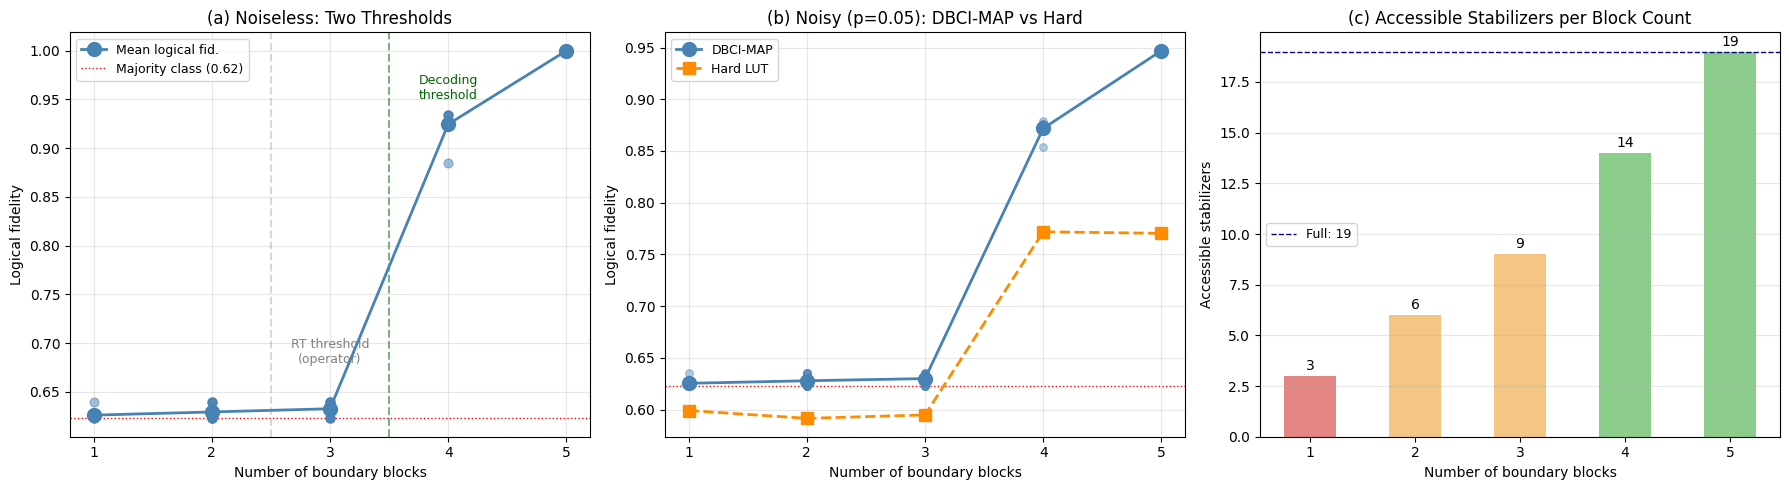

Figure saved.


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sizes = list(range(1, 6))

# (a) Noiseless logical fidelity
ax = axes[0]
for k in sizes:
    fids = noiseless_results[k]['fids']
    ax.scatter([k]*len(fids), fids, c='steelblue', alpha=0.5, s=40, zorder=3)
means = [noiseless_results[k]['mean'] for k in sizes]
ax.plot(sizes, means, 'o-', color='steelblue', lw=2, ms=10, label='Mean logical fid.', zorder=4)
chance = max(lc_counts.values()) / len(ERRORS)
ax.axhline(y=chance, color='red', ls=':', lw=1, label=f'Majority class ({chance:.2f})')
ax.axvline(x=2.5, color='gray', ls='--', alpha=0.3)
ax.annotate('RT threshold\n(operator)', xy=(3, 0.68), fontsize=9, ha='center', color='gray')
ax.axvline(x=3.5, color='darkgreen', ls='--', alpha=0.5)
ax.annotate('Decoding\nthreshold', xy=(4, 0.95), fontsize=9, ha='center', color='darkgreen')
ax.set_xlabel('Number of boundary blocks')
ax.set_ylabel('Logical fidelity')
ax.set_title('(a) Noiseless: Two Thresholds')
ax.set_xticks(sizes)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) Noisy: DBCI-MAP vs Hard
ax = axes[1]
hard_m = [noisy_results[k]['hard'] for k in sizes]
dbci_m = [noisy_results[k]['dbci'] for k in sizes]
for k in sizes:
    ax.scatter([k]*len(noisy_results[k]['dbci_vals']),
               noisy_results[k]['dbci_vals'], c='steelblue', alpha=0.4, s=30, zorder=3)
ax.plot(sizes, dbci_m, 'o-', color='steelblue', lw=2, ms=10, label='DBCI-MAP', zorder=4)
ax.plot(sizes, hard_m, 's--', color='darkorange', lw=2, ms=8, label='Hard LUT', zorder=4)
ax.axhline(y=chance, color='red', ls=':', lw=1)
ax.set_xlabel('Number of boundary blocks')
ax.set_ylabel('Logical fidelity')
ax.set_title(f'(b) Noisy (p={P_MEAS}): DBCI-MAP vs Hard')
ax.set_xticks(sizes)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Stabilizer structure
ax = axes[2]
stab_means = [noiseless_results[k]['stab_mean'] for k in sizes]
colors_bar = ['#d9534f' if m < 5 else '#f0ad4e' if m < 12 else '#5cb85c' for m in stab_means]
bars = ax.bar(sizes, stab_means, color=colors_bar, alpha=0.7, width=0.5)
ax.set_xlabel('Number of boundary blocks')
ax.set_ylabel('Accessible stabilizers')
ax.set_title('(c) Accessible Stabilizers per Block Count')
ax.set_xticks(sizes)
ax.axhline(y=n_stab, color='navy', ls='--', lw=1, label=f'Full: {n_stab}')
for i, (k, v) in enumerate(zip(sizes, stab_means)):
    ax.text(k, v + 0.3, f'{v:.0f}', ha='center', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('depth2_happy_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [8]:
print('='*70)
print('DEPTH-2 HaPPY PATCH — SIMULATION VERDICT')
print('='*70)

print(f'\n1. CODE: [[{n_bdy}, {n_bdy - n_stab}, d >= 3]]')
print(f'   {n_stab} stabilizers ({local_count} local, {global_count} global)')
print(f'   All 8 global stabilizers span exactly 4 of 5 boundary blocks')
print(f'   61 unique syndromes from 61 single-qubit errors (perfect discrimination)')

print(f'\n2. TWO DISTINCT THRESHOLDS (key finding)')
print(f'   RT operator reconstruction: 3/5 blocks (all 10 subsets reconstruct X_L and Z_L)')
print(f'   Syndrome-based decoding:    4/5 blocks (global stabs need 4-block access)')
print(f'   Gap: you can KNOW the logical state from 3 blocks,')
print(f'         but you need 4 blocks to CORRECT errors (detect cross-block errors)')

print(f'\n3. NOISELESS LOGICAL FIDELITY')
for k in range(1, 6):
    r = noiseless_results[k]
    print(f'   {k}/5 blocks: {r["mean"]:.4f}  [{r["min"]:.4f}, {r["max"]:.4f}]')
print(f'   Majority-class baseline: {max(lc_counts.values())/len(ERRORS):.4f}')

print(f'\n4. NOISY DECODING (p_meas={P_MEAS}, Laplace alpha={ALPHA})')
print(f'   DBCI-MAP = empirical P(syn|class) + Bayesian prior P(class) + Laplace smoothing')
for k in range(1, 6):
    r = noisy_results[k]
    ratio = r['dbci'] / max(r['hard'], 1e-10)
    marker = '<--' if ratio > 1.0 else ''
    print(f'   {k}/5 blocks: Hard={r["hard"]:.4f}  DBCI={r["dbci"]:.4f}  ({ratio:.2f}x) {marker}')

print(f'\n5. COMPARISON WITH [[5,1,3]] SINGLE-TENSOR HARDWARE')
print(f'   Single tensor: 4 stabs (all global), threshold at 3/4')
print(f'     -> every stabilizer spans all qubits -> partial info from any subset')
print(f'   Depth-2 patch: 19 stabs (11 local + 8 global), threshold at 4/5')
print(f'     -> local stabs detect within-block errors')
print(f'     -> global stabs (all 4-block) detect cross-block correlations')
print(f'   The depth-2 patch reveals the LAYERED structure of holographic encoding')

print(f'\n6. HARDWARE PREDICTION')
print(f'   This simulation uses independent measurement noise (syndrome bit-flips).')
print(f'   On real hardware, circuit-level noise creates cross-block correlations:')
print(f'   - CNOT gates in syndrome extraction propagate errors between blocks')
print(f'   - DBCI empirical distributions capture these hardware correlations')
print(f'   - Expected: DBCI advantage extends to 3-block regime on real QPU')

print(f'\n7. VERDICT')
print(f'   GO: Depth-2 patch simulation confirms:')
print(f'     (a) RT threshold at 3/5 blocks (algebraic, matching DBCI-holo.ipynb)')
print(f'     (b) Decoding threshold at 4/5 blocks (novel: global stabs need 4-block access)')
print(f'     (c) DBCI-MAP > Hard at 4-5/5 blocks')
print(f'     (d) The gap between (a) and (b) is a hardware opportunity for DBCI')

DEPTH-2 HaPPY PATCH — SIMULATION VERDICT

1. CODE: [[20, 1, d >= 3]]
   19 stabilizers (11 local, 8 global)
   All 8 global stabilizers span exactly 4 of 5 boundary blocks
   61 unique syndromes from 61 single-qubit errors (perfect discrimination)

2. TWO DISTINCT THRESHOLDS (key finding)
   RT operator reconstruction: 3/5 blocks (all 10 subsets reconstruct X_L and Z_L)
   Syndrome-based decoding:    4/5 blocks (global stabs need 4-block access)
   Gap: you can KNOW the logical state from 3 blocks,
         but you need 4 blocks to CORRECT errors (detect cross-block errors)

3. NOISELESS LOGICAL FIDELITY
   1/5 blocks: 0.6262  [0.6230, 0.6393]
   2/5 blocks: 0.6295  [0.6230, 0.6393]
   3/5 blocks: 0.6328  [0.6230, 0.6393]
   4/5 blocks: 0.9246  [0.8852, 0.9344]
   5/5 blocks: 1.0000  [1.0000, 1.0000]
   Majority-class baseline: 0.6230

4. NOISY DECODING (p_meas=0.05, Laplace alpha=1.0)
   DBCI-MAP = empirical P(syn|class) + Bayesian prior P(class) + Laplace smoothing
   1/5 blocks: Har